1. Import Libraries

In [48]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import(
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import(
    EarlyStopping,
    ModelCheckpoint
)

2. Load DataSet

In [49]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

3. Remove Unnecessary Column

In [50]:
df.drop("customerID", axis=1, inplace = True)

4. Handle TotalCharges

In [51]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df["TotalCharges"].isnull().sum()

np.int64(11)

5. Handle Missing Values

In [52]:
df.dropna(inplace = True)
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

6. Separate Features and Target

In [53]:
x = df.drop("Churn", axis = 1)
y = df["Churn"]

7. Encode Target

In [54]:
le = LabelEncoder()
y = le.fit_transform(y)


8. Indentify Features Types

In [55]:
categorical_columns = x.select_dtypes(
    include = "object"
).columns

numerical_columns = x.select_dtypes(
    include = np.number
).columns

/var/folders/83/lyk88fr96bq5vfw5v_m3j0n40000gn/T/ipykernel_43957/1075560464.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = x.select_dtypes(


9. One-Hot Encode Features

In [56]:
x = pd.get_dummies(
    x,
    columns = categorical_columns,
    drop_first = True
)

10. Train-Test Split

In [57]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

11. Check Input Shape

In [58]:
x_train.shape

(5625, 30)

In [59]:
input_dim = x_train.shape[1]

12. Build ANN

In [60]:
model = Sequential([
    Dense(
        64,
        activation = "relu",
        input_shape = (input_dim,) 
    ),
    BatchNormalization(),
    Dropout(0.3),
    Dense(
        32,
        activation="relu"
    ),
    BatchNormalization(),
    Dropout(0.2),
    Dense(
        1,
        activation="sigmoid"
    )
])

/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13. Display Model Summary

In [61]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 192 (768.00 B)

14. Compile the Model

In [62]:
model.compile(
    optimizer = Adam(
        learning_rate = 0.001
    ),
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

15. Configure Callbacks

In [63]:
#Early Stopping

early_stopping = EarlyStopping(
    monitor = "val_loss",
    patience = 10,
    restore_best_weights = True
)

#Checkpoint

checkpoint = ModelCheckpoint(
    "../models/best_ann_model.keras",
    monitor = "val_loss",
    save_best_only = True
)

16. Train the Model

In [64]:
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")
y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

In [65]:
history = model.fit(
    x_train, y_train,
    validation_split = 0.2,
    epochs = 100,
    batch_size = 32,
    callbacks = [early_stopping, checkpoint],
    verbose = 1
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6811 - loss: 0.6211 - val_accuracy: 0.7742 - val_loss: 0.5005
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7649 - loss: 0.5247 - val_accuracy: 0.7867 - val_loss: 0.4717
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7782 - loss: 0.5022 - val_accuracy: 0.7644 - val_loss: 0.4678
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7740 - loss: 0.4939 - val_accuracy: 0.7867 - val_loss: 0.4567
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7753 - loss: 0.4869 - val_accuracy: 0.7876 - val_loss: 0.4677
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7740 - loss: 0.4892 - val_accuracy: 0.7822 - val_loss: 0.4628
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7798 - loss: 0.4807 - val_accuracy: 0.7902 - val_loss: 0.4568
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7844 - loss: 0.4727 - val_accu

17. Plot Learning Curves

##### Loss

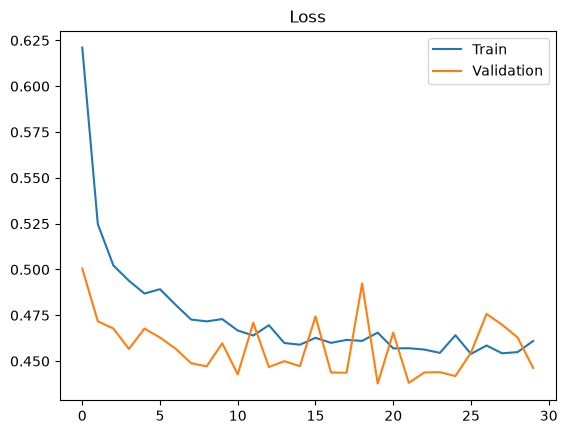

In [73]:
import matplotlib.pyplot as plt
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Train","Validation"])
plt.title("Loss")
plt.show()

##### Accuracy

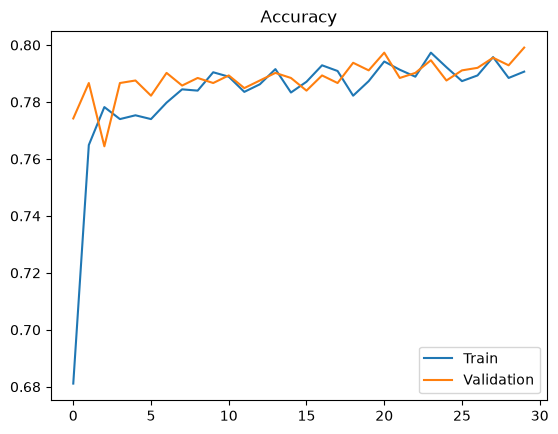

In [74]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Train","Validation"])
plt.title("Accuracy")
plt.show()

18. Initial Evaluation

In [ ]:
loss, accuracy = model.evaluate(
    x_test,
    y_test,
    verbose = 1
)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step - accuracy: 0.7839 - loss: 0.4401


In [76]:
print(loss)
print(accuracy)

0.440127968788147
0.7839374542236328


### Key Points

#### Objective
Designed, trained, and validated an Artificial Neural Network (ANN) for predicting customer churn using TensorFlow and Keras.

#### ANN Architecture
- Input Layer
- Dense Layer (64 neurons, ReLU)
- Batch Normalization
- Dropout (0.3)
- Dense Layer (32 neurons, ReLU)
- Batch Normalization
- Dropout (0.2)
- Output Layer (1 neuron, Sigmoid)

#### Model Configuration
1. Optimizer: Adam (Learning Rate = 0.001)
2. Loss Function: Binary Crossentropy
3. Evaluation Metric: Accuracy
4. Callbacks:
  - EarlyStopping
  - ModelCheckpoint

#### Training Process
- Maximum Epochs: 100
- Batch Size: 32
- Validation Split: 20%
- Best model automatically saved during training.

#### Results
- Final Test Loss: **0.4401**
- Final Test Accuracy: **78.39%**

### Observations
1. Training and validation loss decreased consistently during training.
2. Validation accuracy closely followed training accuracy, indicating good generalization.
3. Batch Normalization and Dropout effectively reduced overfitting.
4. EarlyStopping prevented unnecessary training while preserving the best model.
5. The ANN achieved stable convergence without signs of unstable learning.

#### Key Learnings
- ANN architecture design directly influences learning performance.
- Monitoring validation metrics is essential for preventing overfitting.
- Deep learning models require careful preprocessing, feature scaling, and regularization.

#### Outcome
A stable and production-ready Artificial Neural Network has been successfully trained and is ready for detailed performance evaluation using classification metrics.